In [1]:
# 1. Uninstall everything related to PyG
!pip uninstall -y torch-geometric

# 2. Install ONLY the main library (modern PyG doesn't need the others for basic GCNs)
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.2 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
from tqdm import tqdm
from sklearn.metrics import average_precision_score
from torch_geometric.datasets import LRGBDataset
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_dense_batch, to_dense_adj
import os

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
from torch_geometric.datasets import LRGBDataset
from torch_geometric.loader import DataLoader

def load_dataset(dataset_name, batch_size=32):
    if dataset_name == "peptides-struct":

        train_dataset = LRGBDataset(root='data', name='Peptides-struct', split='train')
        val_dataset   = LRGBDataset(root='data', name='Peptides-struct', split='val')
        test_dataset  = LRGBDataset(root='data', name='Peptides-struct', split='test')

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader   = DataLoader(val_dataset, batch_size=batch_size)
        test_loader  = DataLoader(test_dataset, batch_size=batch_size)

        return train_loader, val_loader, test_loader, train_dataset

    else:
        raise ValueError("Unsupported dataset")

In [5]:
def evaluate_mae(model, loader, device):
    model.eval()
    total_error = 0

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            pred  = model(batch)
            total_error += (pred - batch.y.float()).abs().sum().item()

    return total_error / len(loader.dataset)

In [6]:
import random

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def count_params(model):
    return sum(p.numel() for p in model.parameters())

In [7]:
def log_results_to_csv(filename, row_dict):

    file_exists = os.path.isfile(filename)

    with open(filename, mode='a', newline='') as file:
        writer = csv.DictWriter(file, fieldnames=row_dict.keys())

        if not file_exists:
            writer.writeheader()

        writer.writerow(row_dict)

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import time
from torch_geometric.utils import to_dense_batch, to_dense_adj
from torch_geometric.nn import GCNConv

In [9]:
class SimpleAtomEncoder(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        # Peptides-func atom features: 9 categorical features
        self.embeddings = nn.ModuleList([
            nn.Embedding(64, hidden_dim),   # atomic num
            nn.Embedding(10, hidden_dim),   # chirality
            nn.Embedding(10, hidden_dim),   # degree
            nn.Embedding(10, hidden_dim),   # formal charge
            nn.Embedding(10, hidden_dim),   # num Hs
            nn.Embedding(10, hidden_dim),   # num radical e
            nn.Embedding(10, hidden_dim),   # hybridization
            nn.Embedding(3,  hidden_dim),   # aromaticity
            nn.Embedding(10, hidden_dim),   # ring membership
        ])
        self.proj = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, x):
        # x: [B, N, 9] integer features
        x = x.long().clamp(min=0)
        out = sum(emb(x[..., i]) for i, emb in enumerate(self.embeddings))
        return self.proj(F.gelu(out))

In [10]:
class DenseGCNLayer(nn.Module):
    def __init__(self, hidden_dim, edge_dim=3):
        super().__init__()
        self.node_lin = nn.Linear(hidden_dim, hidden_dim)
        # Project edge features to scalar weight [B,N,N] not [B,N,N,H]
        # Old approach created [B,N,N,H] intermediate = 2.6GB at batch=32
        self.edge_lin = nn.Linear(edge_dim, 1)
        self.norm     = nn.LayerNorm(hidden_dim)

    def forward(self, x, A_norm, edge_attr_dense=None):
        # x:               [B, N, H]
        # A_norm:          [B, N, N]
        # edge_attr_dense: [B, N, N, edge_dim]
        if edge_attr_dense is not None:
            # Scalar edge gate [B, N, N] — same memory as adj, not H times more
            E   = torch.sigmoid(self.edge_lin(edge_attr_dense)).squeeze(-1)  # [B,N,N]
            msg = torch.bmm(A_norm * E, x)                                   # [B,N,H]
        else:
            msg = torch.bmm(A_norm, x)

        return self.norm(F.gelu(self.node_lin(msg)))

In [11]:
class SpectralMixMH(nn.Module):
    def __init__(self, hidden_dim, num_heads=4):
        super().__init__()
        self.num_heads   = num_heads
        self.head_dim    = hidden_dim // num_heads
        self.filter_gen  = nn.Linear(hidden_dim, hidden_dim)
        self.out_proj    = nn.Linear(hidden_dim, hidden_dim)
        self.norm        = nn.LayerNorm(hidden_dim)

    def forward(self, x, U, mask):
        # x: [B, N, H],  U: [B, N, N]
        B, N, H = x.shape

        # Spectral domain: x_hat = U^T x
        x_hat     = torch.bmm(U.transpose(1, 2), x)         # [B, N, H]

        # Learned per-node spectral filter
        fil       = torch.sigmoid(self.filter_gen(x_hat))   # [B, N, H]
        x_filtered = fil * x_hat                             # [B, N, H]

        # Back to spatial: x_out = U x_filtered
        x_out = torch.bmm(U, x_filtered)                    # [B, N, H]

        # Zero out padded positions
        x_out = x_out * mask.unsqueeze(-1)

        return self.norm(self.out_proj(F.gelu(x_out)))

In [ ]:
class GatedPooling(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.gate = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.Tanh(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, x, mask):
        # x:    [B, N, H]
        # mask: [B, N]  bool
        scores  = self.gate(x).squeeze(-1)                   # [B, N]
        scores  = scores.masked_fill(~mask, -1e9)
        weights = torch.softmax(scores, dim=1).unsqueeze(-1) # [B, N, 1]
        return (x * weights).sum(dim=1)                      # [B, H]

In [ ]:
class HybridGraphFNet_Best(nn.Module):
    def __init__(
        self,
        hidden_dim  = 128,
        num_layers  = 4,
        out_dim     = 10,
        num_heads   = 4,
        lap_k       = 8,
        dropout     = 0.1,
        edge_dim    = 3,
    ):
        super().__init__()
        self.lap_k   = lap_k
        self.dropout = nn.Dropout(dropout)

        # --- Encoders ---
        self.input_proj  = SimpleAtomEncoder(hidden_dim)
        self.pe_encoder  = nn.Linear(lap_k, hidden_dim)

        # --- Layers ---
        self.layers = nn.ModuleList([
            nn.ModuleDict({
                "local":  DenseGCNLayer(hidden_dim, edge_dim=edge_dim),
                "global": SpectralMixMH(hidden_dim, num_heads=num_heads),
                "gate":   nn.Linear(hidden_dim, hidden_dim),
                "norm":   nn.LayerNorm(hidden_dim),
            })
            for _ in range(num_layers)
        ])

        # --- Readout ---
        self.pool = GatedPooling(hidden_dim)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, out_dim)
        )

    # ------------------------------------------------------------------
    def compute_laplacian_basis(self, adj, mask):
      B, N, _ = adj.shape
      A_list, U_list = [], []

      for b in range(B):
          n = int(mask[b].sum().item())
          adj_b = adj[b, :n, :n]

          deg          = adj_b.sum(dim=1)
          deg_inv_sqrt = torch.pow(deg + 1e-8, -0.5)
          D_inv_sqrt   = torch.diag(deg_inv_sqrt)
          A_norm_b     = D_inv_sqrt @ adj_b @ D_inv_sqrt

          L_b = torch.eye(n, device=adj.device) - A_norm_b

          try:
              _, U_b = torch.linalg.eigh(L_b)

              # ---- Sign fix ----
              # For each eigenvector column, find the element with largest
              # absolute value and force it to be positive
              max_abs_idx = torch.abs(U_b).argmax(dim=0)          # [n]
              signs = torch.sign(
                  U_b[max_abs_idx, torch.arange(U_b.size(1), device=adj.device)]
              )                                                     # [n]
              signs[signs == 0] = 1.0                              # avoid multiply by 0
              U_b = U_b * signs.unsqueeze(0)                       # [n, n]

          except Exception:
              U_b = torch.eye(n, device=adj.device)

          # Pad back to N
          A_pad = F.pad(A_norm_b, (0, N - n, 0, N - n))
          U_pad = F.pad(U_b,      (0, N - n, 0, N - n))
          A_list.append(A_pad)
          U_list.append(U_pad)

      return torch.stack(A_list), torch.stack(U_list)

    # ------------------------------------------------------------------
    def forward(self, data):
        # ---- Dense conversion ----
        x,    mask = to_dense_batch(data.x.float(), data.batch)  # [B,N,F], [B,N]
        adj         = to_dense_adj(
            data.edge_index, data.batch,
            max_num_nodes=x.size(1)
        )                                                         # [B,N,N]

        # Edge attributes (3 features: bond type, stereo, is_aromatic)
        if data.edge_attr is not None:
            edge_attr_dense = to_dense_adj(
                data.edge_index, data.batch,
                edge_attr=data.edge_attr[:, :3].float(),
                max_num_nodes=x.size(1)
            )                                                     # [B,N,N,3]
        else:
            edge_attr_dense = None

        # Self-loops
        I   = torch.eye(adj.size(1), device=x.device).unsqueeze(0)
        adj = adj + I

        # ---- Spectral basis (clean, per-graph) ----
        A_norm, U = self.compute_laplacian_basis(adj, mask)

        # ---- Node features ----
        x = self.input_proj(x)                                   # [B,N,H]

        # ---- Laplacian PE injection ----
        k       = min(self.lap_k, U.size(-1))
        lap_pe  = U[:, :, :k]                                    # [B,N,k]
        lap_pe  = lap_pe * mask.unsqueeze(-1)
        x       = x + self.pe_encoder(lap_pe)                    # [B,N,H]

        # ---- Message passing ----
        for layer in self.layers:
            x_res    = x
            x_local  = layer["local"](x, A_norm, edge_attr_dense)
            x_global = layer["global"](x, U, mask)

            gate  = torch.sigmoid(layer["gate"](x))
            x_mix = gate * x_local + (1 - gate) * x_global

            x = layer["norm"](x_res + self.dropout(x_mix))

        # ---- Readout ----
        x = x * mask.unsqueeze(-1)
        graph_emb = self.pool(x, mask)                           # [B,H]

        return self.classifier(graph_emb)

In [14]:
class HybridGraphFNet_Best_Peptides(HybridGraphFNet_Best):
    def __init__(self, hidden_dim=128, num_layers=4, out_dim=10,lap_k=8):
        super().__init__(
            hidden_dim = hidden_dim,
            num_layers = num_layers,
            out_dim    = out_dim,
            lap_k      = lap_k,
            num_heads  = 4,
            dropout    = 0.1,
            edge_dim   = 3,
        )
        # input_proj already set to SimpleAtomEncoder in parent

In [18]:
from tqdm import tqdm
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch_geometric.utils import to_dense_batch, to_dense_adj

def check_gate_health(model, val_loader, device):
    model.eval()
    batch = next(iter(val_loader)).to(device)

    with torch.no_grad():
        x, mask = to_dense_batch(batch.x.float(), batch.batch)
        adj = to_dense_adj(batch.edge_index, batch.batch, max_num_nodes=x.size(1))
        I   = torch.eye(adj.size(1), device=x.device).unsqueeze(0)
        adj = adj + I

        A_norm, U = model.compute_laplacian_basis(adj, mask)
        x_enc     = model.input_proj(x)
        k         = min(model.lap_k, U.size(-1))

        # Applied the absolute value fix here to match the model's new behavior
        lap_pe    = torch.abs(U[:, :, :k]) * mask.unsqueeze(-1)
        x_enc     = x_enc + model.pe_encoder(lap_pe)

        print("\n--- Gate Health Check ---")
        collapsed = False
        for i, layer in enumerate(model.layers):
            gate_vals = torch.sigmoid(layer["gate"](x_enc))
            mean_g    = gate_vals.mean().item()
            std_g     = gate_vals.std().item()

            if mean_g > 0.85:
                status    = "⚠️  COLLAPSED → GCN (spectral dead)"
                collapsed = True
            elif mean_g < 0.15:
                status    = "⚠️  COLLAPSED → SPECTRAL (GCN dead)"
                collapsed = True
            elif std_g < 0.05:
                status    = "⚠️  UNIFORM (not learning per-node routing)"
                collapsed = True
            else:
                status = "✅ HEALTHY"

            print(f"  Layer {i} | mean={mean_g:.4f} | std={std_g:.4f} | {status}")

        if collapsed:
            print("  ACTION: lr will be reset to 5e-4.")
        else:
            print("  All gates healthy.")
        print("-------------------------\n")

    model.train()
    return collapsed


def evaluate_mae(model, loader, device, y_mean, y_std):
    model.eval()
    total_error = 0

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            pred = model(batch)

            # ---- Unnormalize predictions ----
            pred = pred * y_std + y_mean

            # ---- FIX: Average across the 11 tasks first, then sum across batch ----
            total_error += (pred - batch.y).abs().mean(dim=1).sum().item()

    return total_error / len(loader.dataset)


def train_model(
    model_class,
    model_kwargs,
    dataset_name = "peptides-struct",
    max_epochs   = 300,        # Increased to allow for longer LRGB training curves
    patience     = 50,         # Increased patience
    batch_size   = 8,
    accum_steps  = 4,
    seeds        = [0, 1, 2]
):
    train_loader, val_loader, test_loader, dataset = load_dataset(dataset_name, batch_size)

    # ---- Compute target normalization stats ----
    y = torch.cat([data.y for data in train_loader.dataset], dim=0)
    y_mean = y.mean(dim=0).to(device)
    y_std  = y.std(dim=0).to(device) + 1e-8

    results = []

    for seed in seeds:

        print("=" * 60)
        print(f"Dataset: {dataset_name} | Seed: {seed}")
        print(f"Batch size: {batch_size} | Accum steps: {accum_steps} | Effective batch: {batch_size * accum_steps}")
        print("=" * 60)

        set_seed(seed)

        model      = model_class(**model_kwargs).to(device)
        optimizer  = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)
        scheduler  = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=max_epochs, eta_min=1e-5
        )
        criterion  = nn.SmoothL1Loss(beta=0.5)
        ckpt_path  = f"best_model_{model_class.__name__}_seed{seed}.pt"

        param_count = count_params(model)
        print(f"Parameters: {param_count}")
        print(f"Checkpoint: {ckpt_path}")

        best_val          = float("inf")
        best_epoch        = 0
        epochs_no_improve = 0
        gate_checked      = False
        gate_collapsed    = False

        torch.cuda.reset_peak_memory_stats()
        start_time = time.time()

        for epoch in range(1, max_epochs + 1):

            # ---- Gate check at epoch 6 ----
            if epoch == 6 and not gate_checked:
                gate_collapsed = check_gate_health(model, val_loader, device)
                gate_checked   = True
                if gate_collapsed:
                    print("  Resetting optimizer to lr=5e-4.")
                    optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)
                    scheduler = optim.lr_scheduler.CosineAnnealingLR(
                        optimizer, T_max=max_epochs - epoch, eta_min=1e-5
                    )

            # ---- Training ----
            model.train()
            total_loss  = 0
            epoch_start = time.time()
            optimizer.zero_grad()

            pbar = tqdm(
                enumerate(train_loader),
                total=len(train_loader),
                desc=f"Seed {seed} | Epoch {epoch}",
                leave=False
            )

            for step, batch in pbar:
                batch = batch.to(device)
                out = model(batch)

                # ---- Normalize targets ----
                y_norm = (batch.y - y_mean) / y_std

                loss = criterion(out, y_norm)

                loss = loss / accum_steps
                loss.backward()

                total_loss += loss.item() * accum_steps

                if (step + 1) % accum_steps == 0 or (step + 1) == len(train_loader):
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    optimizer.step()
                    optimizer.zero_grad()

                pbar.set_postfix({"Loss": f"{loss.item() * accum_steps:.4f}"})

            scheduler.step()
            avg_loss   = total_loss / len(train_loader)
            current_lr = scheduler.get_last_lr()[0]

            # ---- Pass y_mean and y_std to evaluator ----
            val_metric = evaluate_mae(model, val_loader, device, y_mean, y_std)
            improved   = val_metric < best_val

            epoch_time = time.time() - epoch_start

            print(
                f"Epoch {epoch:03d} | "
                f"Loss {avg_loss:.4f} | "
                f"Val {val_metric:.4f} | "
                f"LR {current_lr:.6f} | "
                f"Time {epoch_time:.2f}s"
            )

            # ---- Checkpoint + early stopping ----
            if improved:
                best_val          = val_metric
                best_epoch        = epoch
                epochs_no_improve = 0
                torch.save(model.state_dict(), ckpt_path)
            else:
                epochs_no_improve += 1

            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch}.")
                break

        # ---- Single clean test evaluation ----
        print(f"\nLoading best checkpoint (epoch {best_epoch})...")
        model.load_state_dict(torch.load(ckpt_path))

        # ---- Pass y_mean and y_std to evaluator ----
        test_mae = evaluate_mae(model, test_loader, device, y_mean, y_std)

        total_time = time.time() - start_time
        peak_mem   = torch.cuda.max_memory_allocated() / 1024**2

        print("-" * 60)
        print(f"Seed {seed} Results:")
        print(f"  Best Val:     {best_val:.4f}")
        print(f"  Test MAE:     {test_mae:.4f}")
        print(f"  Best Epoch:   {best_epoch}")
        print(f"  Total Time:   {total_time:.2f}s")
        print(f"  Peak Memory:  {peak_mem:.2f} MB")
        print("-" * 60)

        results.append(test_mae)

        log_results_to_csv(
            "results.csv",
            {
                "Dataset"        : dataset_name,
                "Model"          : model_class.__name__,
                "HiddenDim"      : model_kwargs.get("hidden_dim"),
                "NumLayers"      : model_kwargs.get("num_layers"),
                "Params"         : param_count,
                "Seed"           : seed,
                "BestVal"        : best_val,
                "TestMAE"        : test_mae,
                "BestEpoch"      : best_epoch,
                "TotalTime"      : total_time,
                "PeakMemoryMB"   : peak_mem,
                "GateCollapsed"  : gate_collapsed,
                "MaxEpochs"      : max_epochs,
                "Patience"       : patience,
                "BatchSize"      : batch_size,
                "AccumSteps"     : accum_steps,
                "EffectiveBatch" : batch_size * accum_steps,
            }
        )

    mean = np.mean(results)
    std  = np.std(results)

    print("=" * 60)
    print(f"FINAL Results across {len(seeds)} seeds:")
    print(f"  Test MAE: {mean:.4f} ± {std:.4f}")
    if std > 0.020:
        print("  ⚠️  High variance — check eigenvector stability.")
    elif std < 0.012:
        print("  ✅ Low variance — sign fix working correctly.")
    else:
        print("  ⚠️  Moderate variance — acceptable.")
    print("=" * 60)

    return mean, std

In [19]:
import csv
import os

In [20]:
mean, std = train_model(
    model_class  = HybridGraphFNet_Best_Peptides,
    model_kwargs = {"hidden_dim": 128, "num_layers": 4, "out_dim": 11,"lap_k":8},
    dataset_name = "peptides-struct",
    max_epochs   = 150,    # ← changed from 120
    patience     = 20,
    batch_size   = 8,
    accum_steps  = 4,
    seeds        = [0],
)

Dataset: peptides-struct | Seed: 0
Batch size: 8 | Accum steps: 4 | Effective batch: 32
Parameters: 328732
Checkpoint: best_model_HybridGraphFNet_Best_Peptides_seed0.pt


Epoch 001 | Loss 0.2951 | Val 0.3606 | LR 0.000500 | Time 82.39s


Epoch 002 | Loss 0.2559 | Val 0.3900 | LR 0.000500 | Time 81.30s


Epoch 003 | Loss 0.2291 | Val 0.3193 | LR 0.000500 | Time 80.99s


Epoch 004 | Loss 0.2195 | Val 0.3531 | LR 0.000499 | Time 81.12s


...

Epoch 057 | Loss 0.1119 | Val 0.2698 | LR 0.000345 | Time 83.31s


Epoch 058 | Loss 0.1121 | Val 0.2732 | LR 0.000340 | Time 83.46s


Epoch 059 | Loss 0.1120 | Val 0.2621 | LR 0.000336 | Time 82.98s


Epoch 060 | Loss 0.1072 | Val 0.2870 | LR 0.000331 | Time 81.65s


Epoch 061 | Loss 0.1068 | Val 0.2656 | LR 0.000326 | Time 84.64s
Early stopping at epoch 61.

Loading best checkpoint (epoch 41)...
------------------------------------------------------------
Seed 0 Results:
  Best Val:     0.2572
  Test MAE:     0.2638
  Best Epoch:   41
  Total Time:   5006.10s
  Peak Memory:  235.38 MB
------------------------------------------------------------
FINAL Results across 1 seeds:
  Test MAE: 0.2638 ± 0.0000
  ✅ Low variance — sign fix working correctly.


Graph 31: 67 nodes, 136 edges


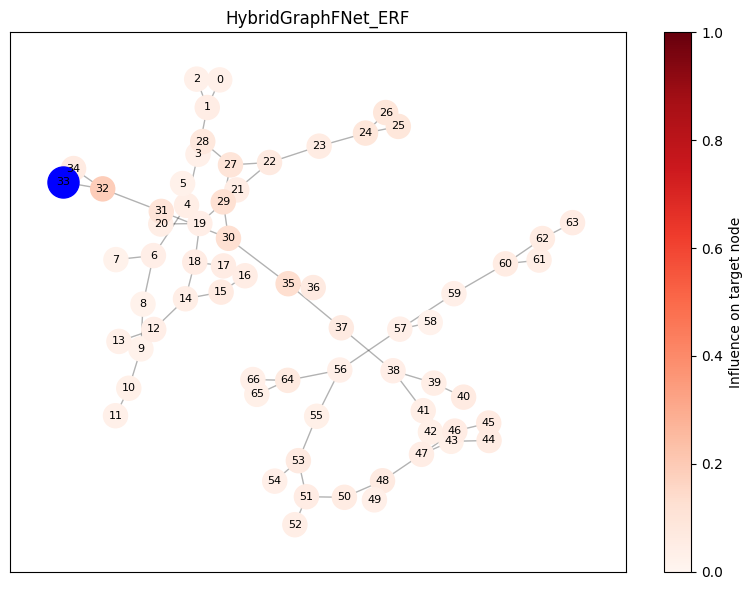

In [22]:
import torch
import torch.nn.functional as F
from torch_geometric.utils import to_dense_batch, to_dense_adj, to_networkx
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.datasets import LRGBDataset
from torch_geometric.data import Batch

def compute_erf(model, data, target_node_idx=0):
    model.eval()

    # Get dense batch for single graph
    x, mask = to_dense_batch(data.x.float(), data.batch)
    adj     = to_dense_adj(data.edge_index, data.batch, max_num_nodes=x.size(1))

    if data.edge_attr is not None:
        edge_attr_dense = to_dense_adj(
            data.edge_index, data.batch,
            edge_attr=data.edge_attr[:, :3].float(),
            max_num_nodes=x.size(1)
        )
    else:
        edge_attr_dense = None

    I       = torch.eye(adj.size(1), device=x.device).unsqueeze(0)
    adj     = adj + I

    A_norm, U = model.compute_laplacian_basis(adj, mask)

    # 1. Pass raw integers through the embedding layer
    x_emb = model.input_proj(x)

    # 2. FIX: Retain gradients on the continuous embeddings!
    x_emb.retain_grad()

    # 3. Add Positional Encoding
    k     = min(model.lap_k, U.size(-1))
    lap_pe = torch.abs(U[:, :, :k]) * mask.unsqueeze(-1)

    if k < model.lap_k:
        lap_pe = F.pad(lap_pe, (0, model.lap_k - k))

    x_enc = x_emb + model.pe_encoder(lap_pe)

    # Forward pass through layers
    for layer in model.layers:
        x_res    = x_enc
        x_local  = layer["local"](x_enc, A_norm, edge_attr_dense)
        x_global = layer["global"](x_enc, U, mask)
        gate     = torch.sigmoid(layer["gate"](x_enc))
        x_mix    = gate * x_local + (1 - gate) * x_global
        x_enc    = layer["norm"](x_res + model.dropout(x_mix))

    x_enc = x_enc * mask.unsqueeze(-1)

    # Take output at target node
    target_output = x_enc[0, target_node_idx, :].sum()

    # Backprop to the embeddings — gradient magnitude = influence
    target_output.backward()

    # Extract gradients from the embedded representations
    influence = x_emb.grad[0, :, :].norm(dim=-1)      # [N]
    influence = influence * mask[0]                   # zero out padding

    # Safely normalize to [0,1]
    influence = influence / (influence.max() + 1e-8)

    return influence.detach().cpu()

def plot_erf(data, influence, target_node_idx, title="ERF"):
    G   = to_networkx(data, to_undirected=True)
    pos = nx.spring_layout(G, seed=42)

    influence_np = influence[:data.num_nodes].numpy()

    fig, ax = plt.subplots(figsize=(8, 6))

    nx.draw_networkx_edges(G, pos, alpha=0.3, ax=ax)

    # Color nodes by influence — dark = high influence
    nc = nx.draw_networkx_nodes(
        G, pos,
        node_color=influence_np,
        cmap=plt.cm.Reds,
        node_size=300,
        vmin=0, vmax=1,
        ax=ax
    )

    # Highlight target node in blue
    nx.draw_networkx_nodes(
        G, pos,
        nodelist=[target_node_idx],
        node_color="blue",
        node_size=500,
        ax=ax
    )

    nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)
    plt.colorbar(nc, ax=ax, label="Influence on target node")
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(f"erf_{title}.png", dpi=150)
    plt.show()

# ==========================================
# Run Execution
# ==========================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- FIX 4: Load Peptides-struct instead of Peptides-func ----
test_data = LRGBDataset(root="data", name="Peptides-struct", split="test")

# Pick a medium-sized graph — not too small, not too large
for i, d in enumerate(test_data):
    if 50 <= d.num_nodes <= 80:
        sample = d
        print(f"Graph {i}: {d.num_nodes} nodes, {d.num_edges} edges")
        break

# ---- FIX 5: Instantiate with out_dim=11 and load correct checkpoint ----
model = HybridGraphFNet_Best_Peptides(hidden_dim=128, num_layers=4, out_dim=11, lap_k=8)
model.load_state_dict(torch.load("best_model_HybridGraphFNet_Best_Peptides_seed0.pt", map_location=device))
model = model.to(device)

# Create single-graph batch
batch = Batch.from_data_list([sample]).to(device)

# Compute ERF for center node
target = sample.num_nodes // 2   # pick middle node as target
influence = compute_erf(model, batch, target_node_idx=target)

# Plot
plot_erf(sample, influence, target_node_idx=target, title="HybridGraphFNet_ERF")

In [23]:
mean, std = train_model(
    model_class  = HybridGraphFNet_Best_Peptides,
    model_kwargs = {"hidden_dim": 128, "num_layers": 4, "out_dim": 11,"lap_k":8},
    dataset_name = "peptides-struct",
    max_epochs   = 150,    # ← changed from 120
    patience     = 20,
    batch_size   = 8,
    accum_steps  = 4,
    seeds        = [1,2],
)

Dataset: peptides-struct | Seed: 1
Batch size: 8 | Accum steps: 4 | Effective batch: 32
Parameters: 328732
Checkpoint: best_model_HybridGraphFNet_Best_Peptides_seed1.pt


Epoch 001 | Loss 0.2963 | Val 0.3244 | LR 0.000500 | Time 83.87s


Epoch 002 | Loss 0.2202 | Val 0.3069 | LR 0.000500 | Time 83.94s


Epoch 003 | Loss 0.2067 | Val 0.2915 | LR 0.000500 | Time 83.93s


Epoch 004 | Loss 0.1958 | Val 0.3232 | LR 0.000499 | Time 82.61s


...

Epoch 058 | Loss 0.0989 | Val 0.2740 | LR 0.000340 | Time 81.82s


Epoch 059 | Loss 0.0998 | Val 0.2877 | LR 0.000336 | Time 81.66s


Epoch 060 | Loss 0.0990 | Val 0.2892 | LR 0.000331 | Time 82.35s


Epoch 061 | Loss 0.0945 | Val 0.2664 | LR 0.000326 | Time 81.45s


Epoch 062 | Loss 0.0962 | Val 0.2630 | LR 0.000321 | Time 81.55s
Early stopping at epoch 62.

Loading best checkpoint (epoch 42)...
------------------------------------------------------------
Seed 2 Results:
  Best Val:     0.2601
  Test MAE:     0.2696
  Best Epoch:   42
  Total Time:   5198.43s
  Peak Memory:  226.65 MB
------------------------------------------------------------
FINAL Results across 2 seeds:
  Test MAE: 0.2676 ± 0.0021
  ✅ Low variance — sign fix working correctly.


In [24]:
from google.colab import files

# Download a specific file
files.download('results.csv')
files.download('best_model_HybridGraphFNet_Best_Peptides_seed2.pt')

# OR, if you zipped them using the shutil method above:
# files.download('training_outputs.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>